In [15]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from lifelines import CoxPHFitter
from pathlib import Path
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path('/data/gusev/USERS/jpconnor/data/')
COMPASS_DATA_PATH = DATA_PATH / 'CAIA/COMPASS/'

In [16]:
surv_df = pd.read_csv(COMPASS_DATA_PATH / 'survival_analysis/PROFILE/prediction_inputs/aggregated_landmark0.csv')
genomics_df = pd.read_csv(DATA_PATH / 'clinical_text_embedding_project/clinical_and_genomic_features/complete_germline_data_df.csv.gz')

surv_cols = ['DFCI_MRN', 'PLATINUM', 't_platinum', 'AGE_AT_TREATMENTSTART', 'PSA__last', 'PSA__max', 'PSA__mean', 'PSA__min', 
             'Testosterone__last', 'Testosterone__max', 'Testosterone__mean', 'Testosterone__min']
genomics_cols = ['DFCI_MRN'] + [col for col in genomics_df.columns 
                                if (('prostate' in col.lower()) and ('specific' in col.lower())) or
                                ('testosterone' in col.lower())]
genomics_pred_df = (surv_df[surv_cols].merge(genomics_df[genomics_cols], on='DFCI_MRN')).dropna()

float_cols = list(set(genomics_pred_df.columns) - {'DFCI_MRN', 'PLATINUM', 't_platinum'})

genomics_pred_df[float_cols] = StandardScaler().fit_transform(genomics_pred_df[float_cols])

In [77]:
def extract_summary_info(cph_fit, covariate_list):
    df = cph_fit.summary.copy().reset_index()
    return df.loc[df['covariate'].isin(covariate_list), ['covariate', 'coef', 'exp(coef)', 'p']]

def run_association_tests(pred_df, base_cols, pgs_cols, var_to_test, event_col='PLATINUM', duration_col='t_platinum'):
    base_var_fit = CoxPHFitter().fit(pred_df[base_cols + [var_to_test]],
                                     event_col=event_col, duration_col=duration_col)
    base_var_results = extract_summary_info(base_var_fit, [var_to_test])
    base_var_results['run_info'] = 'just_var'
    
    surv_results_dfs = [base_var_results]; 
    pgs_var_associations = [];
    for score in pgs_cols:
        score_fit = CoxPHFitter().fit(pred_df[base_cols + [score]],
                                      event_col=event_col, duration_col=duration_col)
        score_var_fit = CoxPHFitter().fit(pred_df[base_cols + [score, var_to_test]],
                                          event_col=event_col, duration_col=duration_col)

        score_results = extract_summary_info(score_fit, [score])
        score_var_results = extract_summary_info(score_var_fit, [score, var_to_test])

        score_results['run_info'] = 'just_PGS'; score_var_results['run_info'] = 'PGS_and_var';
        surv_results_dfs += [score_results, score_var_results]

        r, p = stats.pearsonr(pred_df[var_to_test], pred_df[score])
        pgs_var_associations.append([var_to_test, score, r, p])
    
    complete_result_df = pd.concat(surv_results_dfs)
    complete_result_df['var_type'] = 'var'
    complete_result_df.loc[complete_result_df['covariate'].isin(pgs_cols), 'var_type'] = 'PGS'
    complete_result_df.sort_values(by=['run_info', 'var_type'], inplace=True)
    complete_result_df = complete_result_df.rename(columns={'p' : 'p-val'})
    
    pgs_var_assoc_df = pd.DataFrame(pgs_var_associations, columns=['var', 'PGS', 'rho', 'p-val'])
    return complete_result_df, pgs_var_assoc_df

def generate_forest_plot(df, x, y, title, figsize=(14,6)):
    plot_df = df.copy()
    df['neglog10p'] = - np.log10(df['p-val'])
    df['sig'] = np.select(
        [df['p-val'] < 0.001,
         df['p-val'] < 0.01,
         df['p-val'] < 0.05],
        ['***', '**', '*'], default='')

    df.sort_values(by=x, inplace=True)

    plt.figure(figsize=figsize)

    sns.scatterplot(data=df,
                    x=x,
                    y=y,
                    size='neglog10p',
                    sizes=(50, 500),
                    legend=False)
    plt.axvline(0, color='grey', linestyle='--')

    # for _, row in df.iterrows():
    #     plt.text(
    #         row[x] + 0.01,
    #         row[y],
    #         row['sig'],
    #         va='center')

    for _, row in df.iterrows():
        plt.text(
            row[x] + 0.01,
            row[y],
            f"p={row['p-val']: 0.3f}",
            va='center')
    
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

In [60]:
psa_pgs = [col for col in genomics_pred_df.columns if 'prostate' in col.lower() and 'PGS' in col]
test_pgs = [col for col in genomics_pred_df.columns if 'testosterone' in col.lower() and 'PGS' in col and 'female' not in col.lower()]

t_col = 't_platinum'; event_col = 'PLATINUM'; age_col = 'AGE_AT_TREATMENTSTART'; var_col = 'PSA__mean';
base_cols = [event_col, t_col, age_col]

psa_mean_pgs_df, psa_pgs_assoc_df = run_association_tests(genomics_pred_df, base_cols, psa_pgs, 'PSA__mean')
test_mean_pgs_df, test_pgs_assoc_df = run_association_tests(genomics_pred_df, base_cols, test_pgs, 'Testosterone__mean')

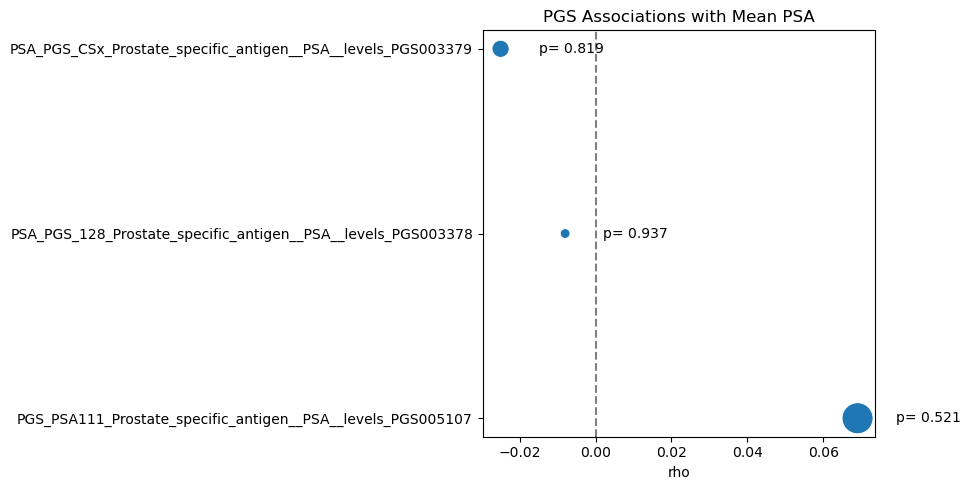

In [78]:
psa_pgs_assoc_df['rho'] = psa_pgs_assoc_df['rho'].round(3)
psa_pgs_assoc_df['p-val'] = psa_pgs_assoc_df['p-val'].round(3)

generate_forest_plot(psa_pgs_assoc_df, x='rho', y='PGS', title='PGS Associations with Mean PSA', figsize=(10,5))

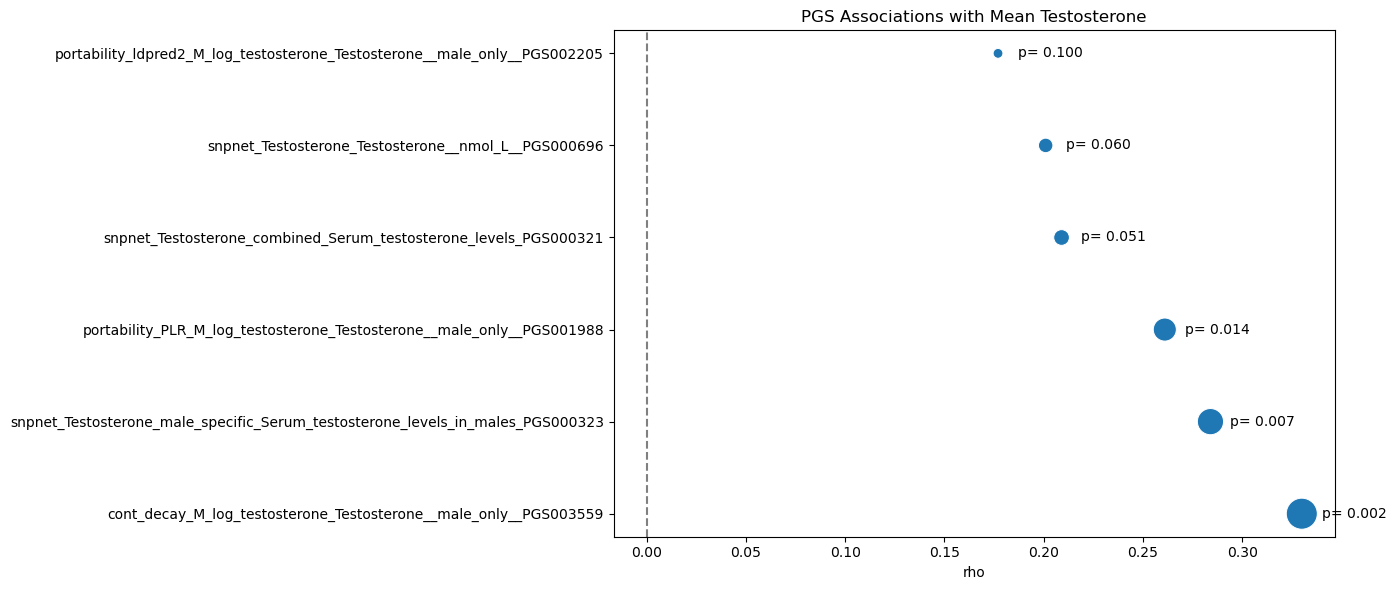

In [79]:
test_pgs_assoc_df['rho'] = test_pgs_assoc_df['rho'].round(3)
test_pgs_assoc_df['p-val'] = test_pgs_assoc_df['p-val'].round(3)

generate_forest_plot(test_pgs_assoc_df, x='rho', y='PGS', title='PGS Associations with Mean Testosterone', figsize=(14,6))

/tmp/ipykernel_1155742/135450619.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['neglog10p'] = - np.log10(df['p-val'])
/tmp/ipykernel_1155742/135450619.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sig'] = np.select(
/tmp/ipykernel_1155742/135450619.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df

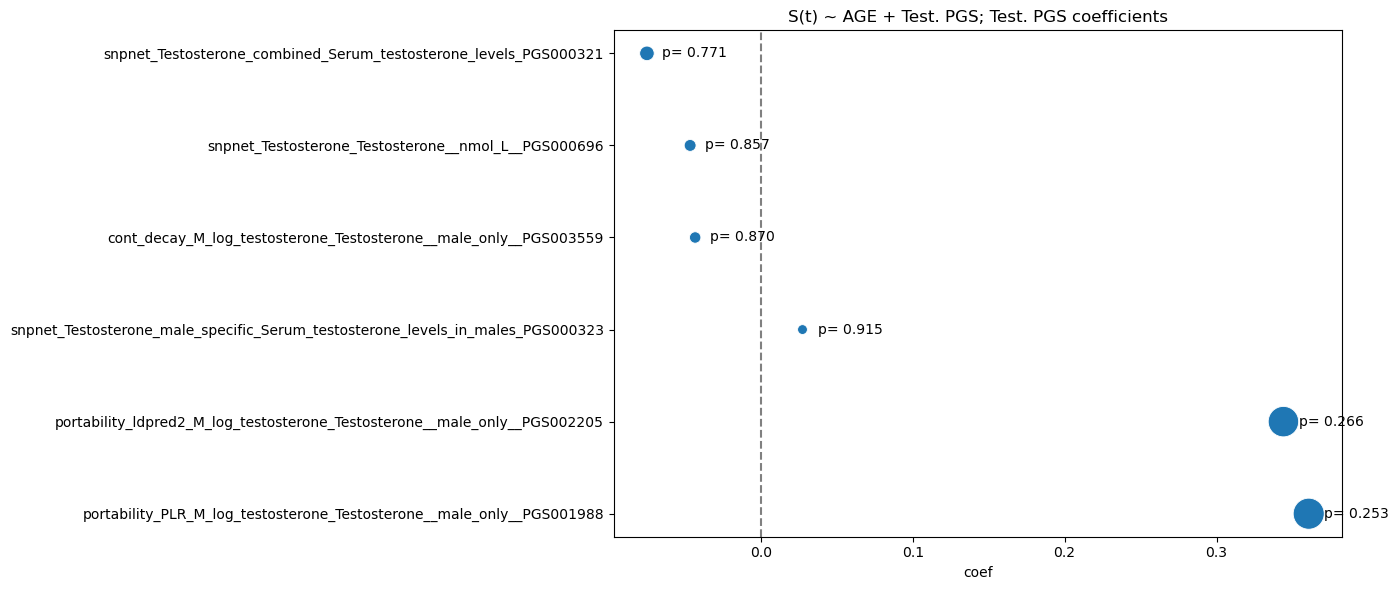

In [80]:
generate_forest_plot(test_mean_pgs_df.loc[test_mean_pgs_df['run_info'] == 'just_PGS'],
                     x='coef', y='covariate', title='S(t) ~ AGE + Test. PGS; Test. PGS coefficients')

/tmp/ipykernel_1155742/135450619.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['neglog10p'] = - np.log10(df['p-val'])
/tmp/ipykernel_1155742/135450619.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sig'] = np.select(
/tmp/ipykernel_1155742/135450619.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df

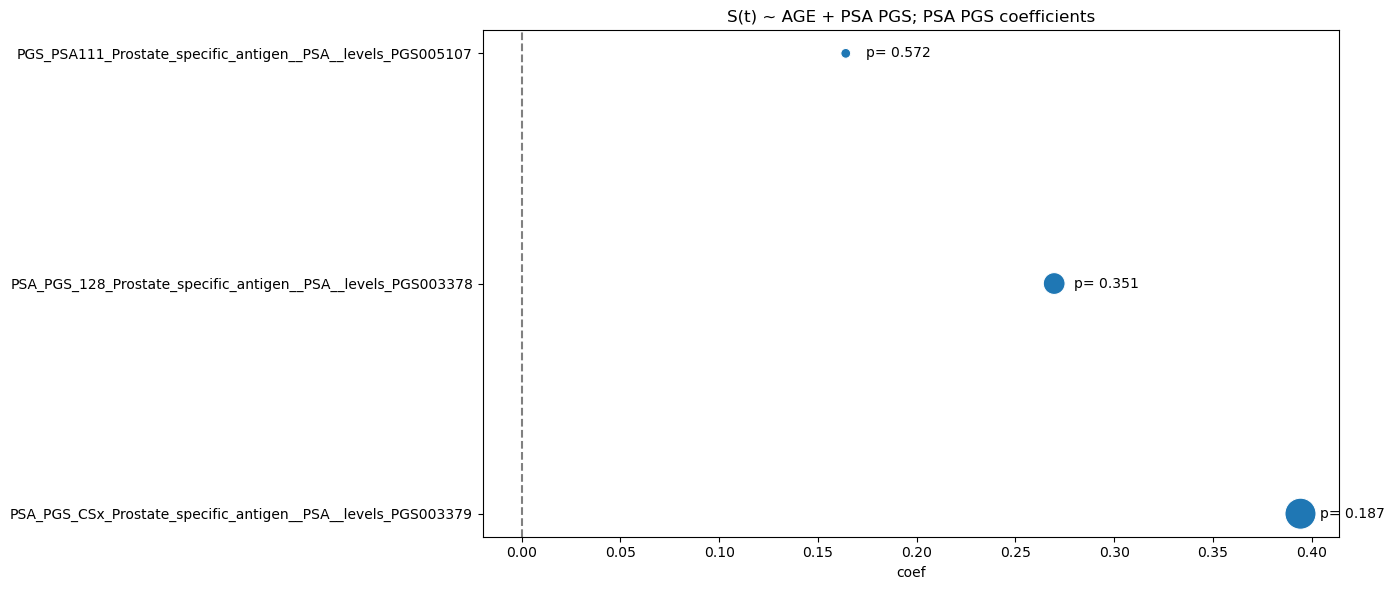

In [81]:
generate_forest_plot(psa_mean_pgs_df.loc[psa_mean_pgs_df['run_info'] == 'just_PGS'],
                     x='coef', y='covariate', title='S(t) ~ AGE + PSA PGS; PSA PGS coefficients')

In [83]:
test_mean_pgs_df['coef'] = test_mean_pgs_df['coef'].round(3)
test_mean_pgs_df['p-val'] = test_mean_pgs_df['p-val'].round(3)

psa_mean_pgs_df['coef'] = psa_mean_pgs_df['coef'].round(3)
psa_mean_pgs_df['p-val'] = psa_mean_pgs_df['p-val'].round(3)



In [85]:
test_mean_pgs_df.loc[(test_mean_pgs_df['run_info'].isin(['PGS_and_var', 'just_var'])) & 
                     (test_mean_pgs_df['var_type'] == 'var')]

,covariate,coef,exp(coef),p-val,run_info,var_type
2,Testosterone__mean,-0.362,0.696015,0.292,PGS_and_var,var
2,Testosterone__mean,-0.410,0.663628,0.220,PGS_and_var,var
2,Testosterone__mean,-0.375,0.687295,0.279,PGS_and_var,var
2,Testosterone__mean,-0.546,0.579065,0.126,PGS_and_var,var
2,Testosterone__mean,-0.467,0.626581,0.176,PGS_and_var,var
2,Testosterone__mean,-0.379,0.684584,0.253,PGS_and_var,var
1,Testosterone__mean,-0.349,0.705671,0.281,just_var,var


In [89]:
test_mean_pgs_df.loc[test_mean_pgs_df['var_type'] == 'var'].groupby('run_info')[['coef', 'exp(coef)', 'p-val']].mean().reset_index()

,run_info,coef,exp(coef),p-val
0,PGS_and_var,-0.423167,0.656195,0.224333
1,just_var,-0.349000,0.705671,0.281000


In [90]:
psa_mean_pgs_df.loc[(psa_mean_pgs_df['run_info'].isin(['PGS_and_var', 'just_var'])) &
                    (psa_mean_pgs_df['var_type'] == 'var')]

,covariate,coef,exp(coef),p-val,run_info,var_type
2,PSA__mean,0.167,1.181676,0.410,PGS_and_var,var
2,PSA__mean,0.212,1.236551,0.311,PGS_and_var,var
2,PSA__mean,0.139,1.149171,0.487,PGS_and_var,var
1,PSA__mean,0.141,1.151877,0.470,just_var,var


In [92]:
psa_mean_pgs_df.loc[psa_mean_pgs_df['var_type'] == 'var'].groupby('run_info')[['coef', 'exp(coef)', 'p-val']].mean().reset_index()

,run_info,coef,exp(coef),p-val
0,PGS_and_var,0.172667,1.189133,0.402667
1,just_var,0.141000,1.151877,0.470000
